# 02. Validation et annotation

Ce notebook examine la cohérence et la validité des annotations produites par un modèle de langage (LLM). L’**annotation par LLM** consiste à utiliser un grand modèle de langage pour attribuer à chaque texte un score de positionnement sur une échelle ordinale, sans intervention humaine systématique. Deux versions du corpus sont mobilisées : le **corpus principal** (texte complet, 10 774 unités) et le **corpus par fenêtres événementielles** (5 905 unités, centrées sur des moments clés). On évalue la **calibration** (la cohérence des scores selon les blocs politiques), l’impact du **Panel B4** (sous-ensemble des députés les plus actifs sur quatre mois), et la correspondance entre indices lexicaux et scores LLM.

## Setup et configuration

Les bibliothèques et les chemins vers les deux versions du corpus sont chargés.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from config import PROJECT_ROOT, RESULTS_DIR, FIGURES_DIR, BLOC_COLORS, BLOC_ORDER, EVENTS, add_events, format_dates

FIG_DIR = Path("../figures")
RES_DIR = Path("../data/results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib as mpl
mpl.rcParams.update({
    'figure.constrained_layout.use': True,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
})

def save(name):
    plt.savefig(FIG_DIR / f'{name}.png')
    plt.show()

## Chargement du corpus

Les deux corpus sont chargés : le corpus principal (texte complet) et le corpus par fenêtres événementielles, qui ne retient que les textes proches d’événements pivots (CIJ, Rafah, mandats CPI, etc.).

In [2]:
from config import CORPUS_V3, CORPUS_V4
df = pd.read_parquet(CORPUS_V3)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M').astype(str)
df['group'] = df.get('group', df.get('groupe_politique', 'UNKNOWN'))

df_v4 = pd.read_parquet(CORPUS_V4)
df_v4['date'] = pd.to_datetime(df_v4['date'])
df_v4['month'] = df_v4['date'].dt.to_period('M').astype(str)

print(f"Corpus principal : {len(df):,} textes. Corpus par fenêtres événementielles : {len(df_v4):,} textes.")

Corpus principal : 10,774 textes. Corpus par fenêtres événementielles : 5,905 textes.


## Fig 06 : Matrice de confusion du positionnement entre corpus

Le **positionnement** est le score attribué à chaque texte sur une échelle de -2 (très favorable à Israël) à +2 (très favorable à la Palestine ou au cessez-le-feu). La matrice croise les annotations du corpus principal (en ligne) et du corpus par fenêtres événementielles (en colonne) pour les textes communs. La diagonale concentre l’accord ; les écarts reflètent les recalibrations induites par le prompt enrichi du corpus événementiel.

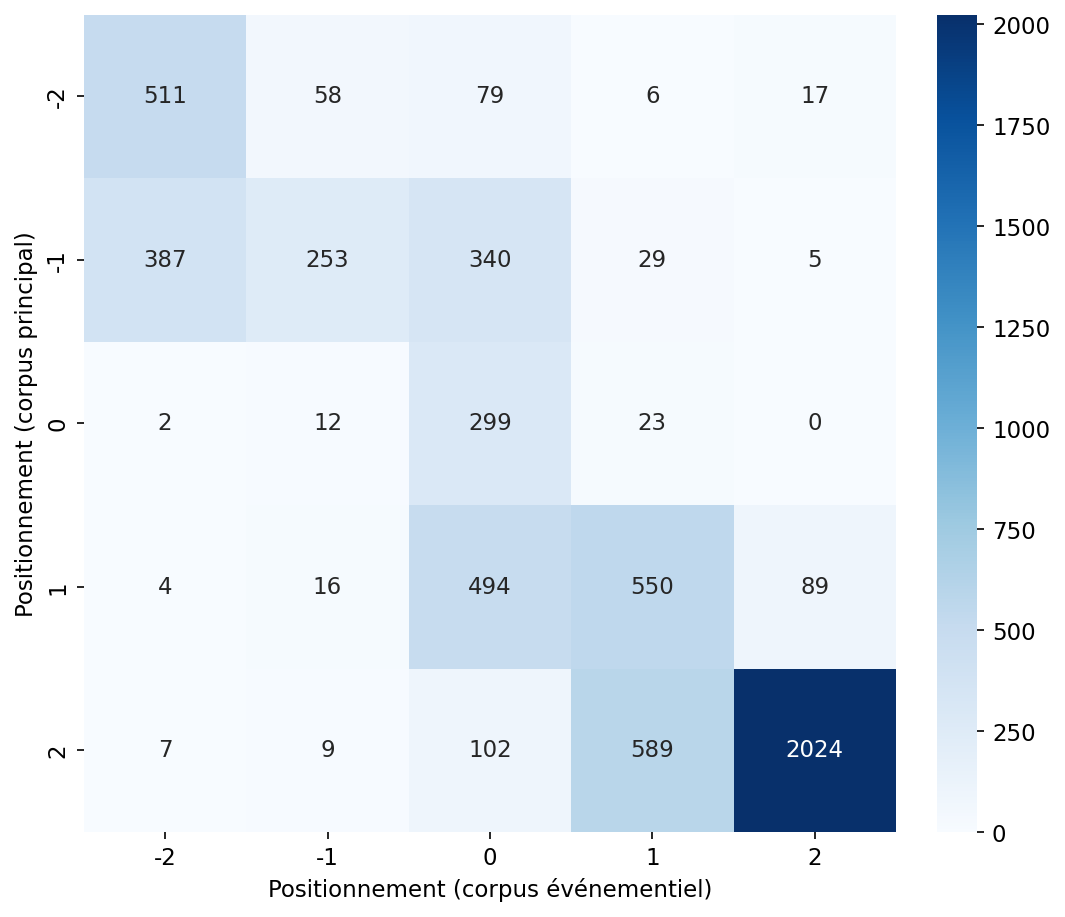

In [3]:
conf = pd.crosstab(df_v4['stance_v3'], df_v4['stance_v4'])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Positionnement (corpus événementiel)')
ax.set_ylabel('Positionnement (corpus principal)')
save('fig06_matrice_confusion_v3_v4')

L’accord inter-annotateur (entre les deux procédures d’annotation) est élevé sur la diagonale : la plupart des textes conservent un score proche entre les deux versions du corpus, avec des recalibrations localisées notamment autour du neutre.

## Fig 07 : Calibration par bloc

La **calibration** désigne la cohérence des scores de positionnement selon les blocs politiques : on vérifie que les distributions par bloc correspondent aux attendus théoriques et que la variance des annotations reste plausible.

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_5952\805725520.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cal, x='bloc', y=col_conf, order=BLOC_ORDER, palette=BLOC_COLORS)


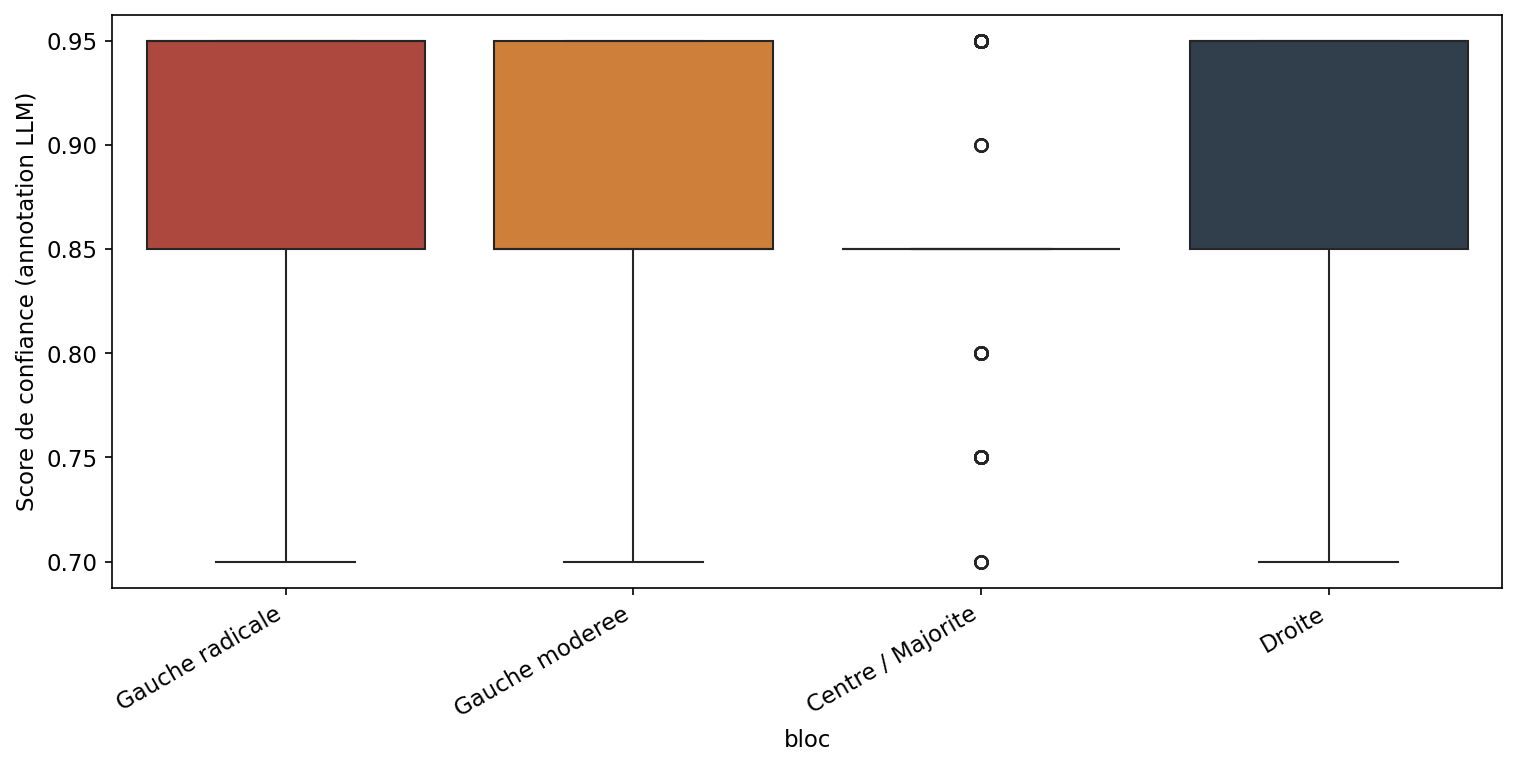

In [4]:
df_cal = df_v4[df_v4['bloc'].isin(BLOC_ORDER)].copy()
df_cal['bloc'] = pd.Categorical(df_cal['bloc'], categories=BLOC_ORDER)
col_conf = 'confidence_v3' if 'confidence_v3' in df_cal.columns else 'confidence'
if col_conf in df_cal.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df_cal, x='bloc', y=col_conf, order=BLOC_ORDER, palette=BLOC_COLORS)
    ax.set_ylabel('Score de confiance (annotation LLM)')
    plt.xticks(rotation=30, ha='right')
    save('fig07_calibration_par_bloc')
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    stance_mean = df_cal.groupby('bloc')['stance_v3'].mean().reindex(BLOC_ORDER)
    ax.bar(stance_mean.index, stance_mean.values, color=[BLOC_COLORS[b] for b in stance_mean.index])
    plt.xticks(rotation=30, ha='right')
    save('fig07_calibration_par_bloc')

La confiance des annotations varie peu entre blocs ; le Centre présente une variance légèrement plus élevée, cohérente avec un positionnement plus nuancé et moins homogène.

## Fig 08 : Panel B4 vs corpus complet

Le **Panel B4** désigne un sous-ensemble de députés sélectionnés pour leur forte activité sur une fenêtre de quatre mois consécutifs ; il permet d’étudier l’évolution des positionnements chez les contributeurs les plus réguliers, au risque de biais de sélection.

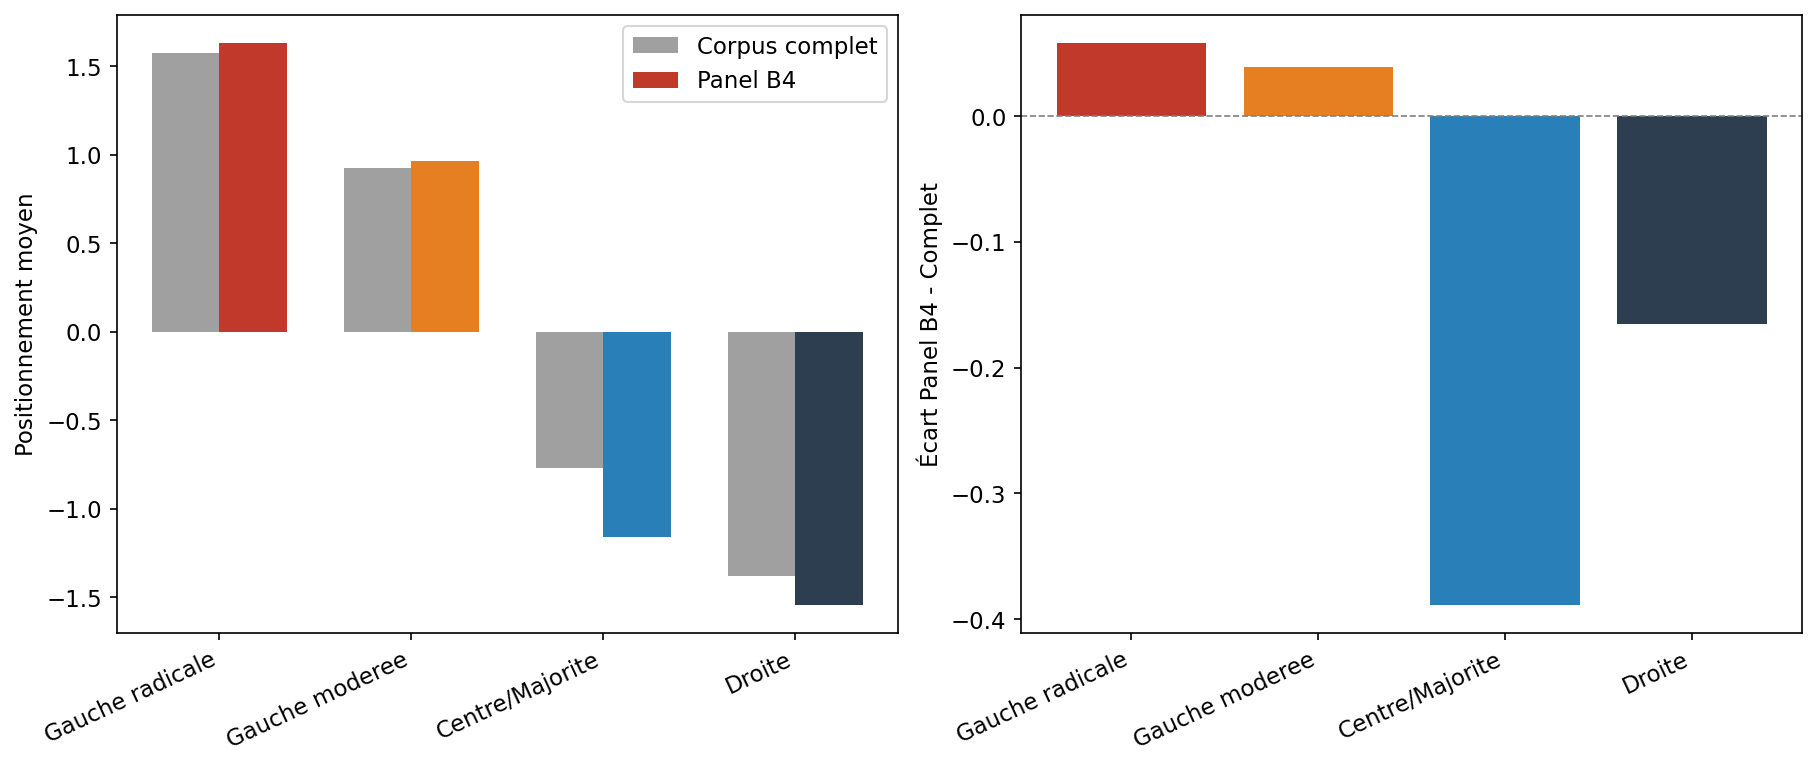

In [5]:
months_per_dep = df.groupby('author')['month'].nunique()
panel_b4 = months_per_dep[months_per_dep >= 18].index.tolist()
df['in_panel_b4'] = df['author'].isin(panel_b4)

stance_complet = df.groupby('bloc')['stance_v3'].agg(['mean', 'count']).reindex(BLOC_ORDER)
stance_panel = df[df['in_panel_b4']].groupby('bloc')['stance_v3'].agg(['mean', 'count']).reindex(BLOC_ORDER)

comp = pd.DataFrame({
    'bloc': BLOC_ORDER,
    'stance_complet': stance_complet['mean'].values,
    'stance_panel_b4': stance_panel['mean'].values,
    'n_complet': stance_complet['count'].astype(int).values,
    'n_panel': stance_panel['count'].astype(int).values,
})
comp['delta'] = comp['stance_panel_b4'] - comp['stance_complet']
comp.to_csv(RES_DIR / 'stance_panel_vs_complet.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(BLOC_ORDER))
w = 0.35
axes[0].bar(x - w/2, comp['stance_complet'], w, label='Corpus complet', color='#888', alpha=0.8)
axes[0].bar(x + w/2, comp['stance_panel_b4'], w, label='Panel B4', color=[BLOC_COLORS[b] for b in BLOC_ORDER])
axes[0].set_xticks(x)
axes[0].set_xticklabels([b.replace(' / ', '/') for b in BLOC_ORDER], rotation=25, ha='right')
axes[0].set_ylabel('Positionnement moyen')
axes[0].legend()

axes[1].bar(x, comp['delta'], color=[BLOC_COLORS[b] for b in BLOC_ORDER])
axes[1].axhline(0, color='grey', ls='--', lw=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([b.replace(' / ', '/') for b in BLOC_ORDER], rotation=25, ha='right')
axes[1].set_ylabel('Écart Panel B4 - Complet')
save('fig08_panel_b4_vs_complet')

Le Centre est le bloc le plus affecté par le passage au Panel B4 : les députés centristes les plus actifs sont en moyenne plus favorables à Israël que l’ensemble du corpus, suggérant une composition différente du sous-échantillon actif.

### Métriques lexical vs LLM

Spearman (direction), Pearson (linéarité), accord de signe (lexical et LLM du même côté de 0).

## Fig 09 : Lexical vs LLM

On compare un indice lexical simple (basé sur des termes-clés) aux scores de positionnement produits par le LLM, afin de valider la convergence des deux approches.

Spearman ρ = 0.5941 ; Pearson r = 0.6178 ; Accord de signe = 73.5 %


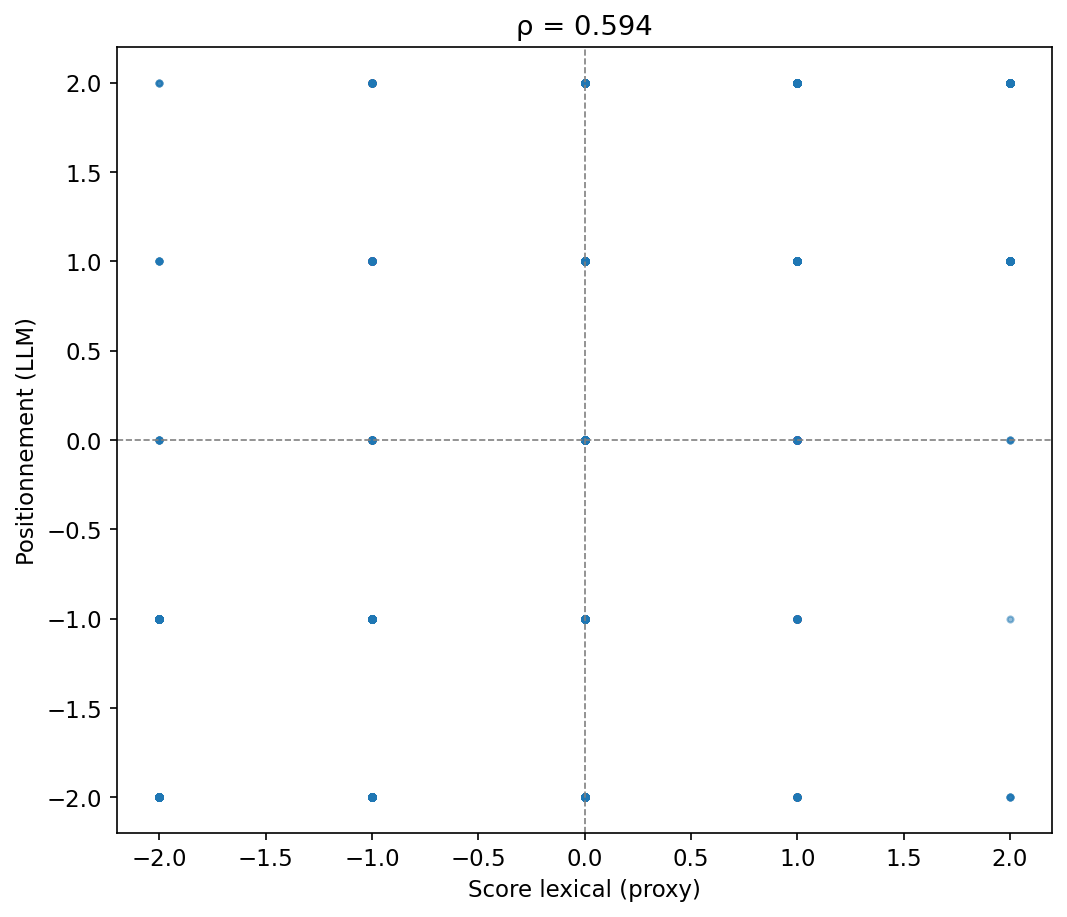

In [ ]:
text_col = 'text_clean' if 'text_clean' in df.columns else 'text'
pro_pal = ['cessez', 'génocide', 'palestine', 'gaza', 'colonie']
pro_isr = ['défendre', 'hamas', 'terroriste', 'otage']

def lexical_score(text):
    if pd.isna(text) or not isinstance(text, str):
        return 0
    t = text.lower()
    s = sum(1 for w in pro_pal if w in t) - sum(1 for w in pro_isr if w in t)
    return np.clip(s, -2, 2)

if 'lexical_score' not in df.columns:
    df['lexical_score'] = df[text_col].apply(lexical_score)
valid = df[['stance_v3', 'lexical_score']].dropna()
spearman = valid['stance_v3'].corr(valid['lexical_score'], method='spearman')
pearson = valid['stance_v3'].corr(valid['lexical_score'], method='pearson')
accord_signe = ((valid['stance_v3'] > 0) == (valid['lexical_score'] > 0)).mean() * 100
print(f"Spearman ρ = {spearman:.4f} ; Pearson r = {pearson:.4f} ; Accord de signe = {accord_signe:.1f} %")
rho = spearman

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(valid['lexical_score'], valid['stance_v3'], alpha=0.15, s=8)
ax.set_xlabel('Score lexical (proxy)')
ax.set_ylabel('Positionnement (LLM)')
ax.set_title(f'ρ = {rho:.3f}')
ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.axvline(0, color='grey', ls='--', lw=0.8)
save('fig09_lexical_vs_annotation')

La corrélation entre le proxy lexical et le score de positionnement LLM valide la cohérence des deux approches : les indices lexicaux simples et les annotations LLM convergent sur le positionnement du discours.